In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# WORLD HAPPINESS INDEX AND INFLATION DATASET ANALYSIS

**This dataset combines World Happiness Index (WHI) scores with inflation metrics across different countries from 2015 to 2023.
It provides insights into how economic conditions such as GDP per capita, inflation, and corruption perception impact happiness levels globally.**

A dataset is provided by Hugging Face: https://huggingface.co/datasets/AgraResearchLab/WorldHappinessIndex_InflationDataset

In [11]:
# Read the dataset
whii_data = pd.read_csv("data/whi_inflation.csv")

In [12]:
whii_data

,Country,Year,Headline Consumer Price Inflation,Energy Consumer Price Inflation,Food Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,GDP deflator Index growth rate,Continent/Region,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,Afghanistan,2015,-0.660000,-4.250000,-0.840000,0.219999,NaN,2.665090,South Asia,3.5750,0.319820,0.302850,0.303350,0.234140,0.365100,0.097190
1,Afghanistan,2016,4.380000,2.070000,5.670000,5.192760,NaN,-2.409509,South Asia,3.3600,0.382270,0.110370,0.173440,0.164300,0.312680,0.071120
2,Afghanistan,2017,4.976000,4.440000,6.940000,5.423228,NaN,2.404000,South Asia,3.7940,0.401477,0.581543,0.180747,0.106180,0.311871,0.061158
3,Afghanistan,2018,0.630000,1.474185,-1.045952,-0.126033,NaN,2.071208,South Asia,3.6320,0.332000,0.537000,0.255000,0.085000,0.191000,0.036000
4,Afghanistan,2019,2.302000,-2.494359,3.794770,NaN,NaN,6.520928,South Asia,3.2030,0.350000,0.517000,0.361000,0.000000,0.158000,0.025000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,Zimbabwe,2019,255.292007,90.808071,86.124371,NaN,NaN,-4.035235,Sub-Saharan Africa,3.6630,0.366000,1.114000,0.433000,0.361000,0.151000,0.089000
1228,Zimbabwe,2020,557.210000,306.431673,601.020236,NaN,NaN,568.971862,Sub-Saharan Africa,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929
1229,Zimbabwe,2021,98.546000,69.820000,105.800000,NaN,NaN,113.294981,Sub-Saharan Africa,3.1450,0.457000,0.649000,0.243000,0.359000,0.157000,0.075000
1230,Zimbabwe,2022,104.705171,97.246550,149.967034,NaN,NaN,113.018434,Sub-Saharan Africa,2.9950,0.947000,0.690000,0.270000,0.329000,0.106000,0.105000


In [13]:
# See the dataset size
whii_data.shape

(1232, 16)

**SIZE: 
1232 rows & 16 columns**

### Columns - types and meanings

In [14]:
whii_data.columns

Index(['Country', 'Year', 'Headline Consumer Price Inflation',
       'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
       'Official Core Consumer Price Inflation', 'Producer Price Inflation',
       'GDP deflator Index growth rate', 'Continent/Region', 'Score',
       'GDP per Capita', 'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [18]:
# I will make them in a more Pythonic style
whii_data.columns = (
    whii_data.columns
    .str.strip()
    .str.lower()
    .str.replace('/', '_')     
    .str.replace(r'\s+', '_', regex = True)
)

In [19]:
whii_data.columns

Index(['country', 'year', 'headline_consumer_price_inflation',
       'energy_consumer_price_inflation', 'food_consumer_price_inflation',
       'official_core_consumer_price_inflation', 'producer_price_inflation',
       'gdp_deflator_index_growth_rate', 'continent_region', 'score',
       'gdp_per_capita', 'social_support', 'healthy_life_expectancy_at_birth',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption'],
      dtype='object')

#### Features Types

In [20]:
whii_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 1232 non-null   object 
 1   year                                    1232 non-null   int64  
 2   headline_consumer_price_inflation       1200 non-null   float64
 3   energy_consumer_price_inflation         1090 non-null   float64
 4   food_consumer_price_inflation           1130 non-null   float64
 5   official_core_consumer_price_inflation  734 non-null    float64
 6   producer_price_inflation                769 non-null    float64
 7   gdp_deflator_index_growth_rate          1211 non-null   float64
 8   continent_region                        1232 non-null   object 
 9   score                                   1232 non-null   float64
 10  gdp_per_capita                          1232 non-null   floa

It seems that no corrections must be done to the variable types but this will be checked later on.
Some variables have NaN values.

#### Variable Optimization

Now let's look at the variables one by one and see what can be done for optimization

##### Country

Meaning: The name of the country where the data is recorded.

In [22]:
whii_data.country.value_counts()

country
Cyprus         11
Afghanistan     9
Algeria         9
Albania         9
Botswana        9
               ..
Maldives        2
Suriname        2
Djibouti        1
Puerto Rico     1
Oman            1
Name: count, Length: 148, dtype: int64

It can be seen that there are a lot of repetitive countries which means that a pivot table can be created for better visualization.

In [25]:
# Description of the variable country
whii_data.country.describe()

count       1232
unique       148
top       Cyprus
freq          11
Name: country, dtype: object

There are 148 countries mentioned if all the names are correct. There are no missing values.
As 'country' is a qualitative variable, I can change the type to "category"".

In [26]:
# Change the type of the variable 'country'
whii_data.country = whii_data.country.astype("category")

In [27]:
# See the unique names of countries
whii_data.country.unique()

['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', ..., 'Uruguay', 'Uzbekistan', 'Vietnam', 'Zambia', 'Zimbabwe']
Length: 148
Categories (148, object): ['Afghanistan', 'Albania', 'Algeria', 'Angola', ..., 'Uzbekistan', 'Vietnam', 'Zambia', 'Zimbabwe']

##### Year

Meaning: The year in which the happiness and economic data were collected (2015-2023).

In [30]:
# Check if all data is valid which means that it is in the range [2015-2023]
if ((whii_data.year < 2015) | (whii_data.year > 2023)).any():
    print("There are invalid values.")
else:
    print("Everything is fine.")

Everything is fine.


In [34]:
whii_data.year.describe()

count    1232.000000
mean     2018.895292
std         2.554602
min      2015.000000
25%      2017.000000
50%      2019.000000
75%      2021.000000
max      2023.000000
Name: year, dtype: float64

The describe method treats 'year' as a quantitative variable but actually it must be treated as a qualitative variable.
That is why I change its type to "category".

In [35]:
whii_data.year = whii_data.year.astype("category")

In [36]:
whii_data.year.describe()

count     1232
unique       9
top       2015
freq       142
Name: year, dtype: int64

In [38]:
whii_data.year.value_counts(dropna = False)

year
2015    142
2018    142
2016    141
2017    141
2019    141
2020    138
2021    135
2022    130
2023    122
Name: count, dtype: int64

The year 2015 is the year with the most occurences together with 2018. The other years have lower counts - maybe some countries do not have records which belong to these years. 

In [37]:
whii_data.year.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1232 entries, 0 to 1231
Series name: year
Non-Null Count  Dtype   
--------------  -----   
1232 non-null   category
dtypes: category(1)
memory usage: 1.7 KB


Hopefully, there are no missing values.

##### Columns 2-6 (Inflation Columns)

Meanings:
- Energy Consumer Price Inflation: The annual percentage change in energy prices (e.g., electricity, fuel).
- Food Consumer Price Inflation: The annual percentage change in food prices.
- GDP Deflator Index Growth Rate: A measure of overall price level changes in the economy, considering inflation.
- Headline Consumer Price Inflation: A broad measure of inflation capturing price changes in consumer goods and services.
- Official Core Consumer Price Inflation: A stable inflation measure that excludes volatile food and energy prices.
- Producer Price Inflation: The annual inflation rate for producers and manufacturers, affecting future consumer prices.

In [54]:
# Check for missing values and variable types which can be corrected using a for loop for all the above-mentioned columns
for col in whii_data.columns[2:7]:
    print(f"Info for {col}:")
    print(whii_data[col].info())
    print("\n" + "-"*50 + "\n")

Info for headline_consumer_price_inflation:
<class 'pandas.core.series.Series'>
RangeIndex: 1232 entries, 0 to 1231
Series name: headline_consumer_price_inflation
Non-Null Count  Dtype  
--------------  -----  
1200 non-null   float64
dtypes: float64(1)
memory usage: 9.8 KB
None

--------------------------------------------------

Info for energy_consumer_price_inflation:
<class 'pandas.core.series.Series'>
RangeIndex: 1232 entries, 0 to 1231
Series name: energy_consumer_price_inflation
Non-Null Count  Dtype  
--------------  -----  
1090 non-null   float64
dtypes: float64(1)
memory usage: 9.8 KB
None

--------------------------------------------------

Info for food_consumer_price_inflation:
<class 'pandas.core.series.Series'>
RangeIndex: 1232 entries, 0 to 1231
Series name: food_consumer_price_inflation
Non-Null Count  Dtype  
--------------  -----  
1130 non-null   float64
dtypes: float64(1)
memory usage: 9.8 KB
None

--------------------------------------------------

Info for offi

Results indicate that there are quite a lot missing values especially in the column 'official_core_consumer_price_inflation' which is 1232 - 734 = 498 NaN values. Later on in the analysis I will look in which observations are the missing values.

In [65]:
whii_data[whii_data["official_core_consumer_price_inflation"].isna()]

,country,year,headline_consumer_price_inflation,energy_consumer_price_inflation,food_consumer_price_inflation,official_core_consumer_price_inflation,producer_price_inflation,gdp_deflator_index_growth_rate,continent_region,score,gdp_per_capita,social_support,healthy_life_expectancy_at_birth,freedom_to_make_life_choices,generosity,perceptions_of_corruption
4,Afghanistan,2019,2.302000,-2.494359,3.794770,NaN,NaN,6.520928,South Asia,3.2030,0.350000,0.517000,0.361000,0.000000,0.158000,0.025000
5,Afghanistan,2020,5.443000,NaN,5.829005,NaN,NaN,5.307120,South Asia,2.5669,0.300706,0.356434,0.266052,0.000000,0.135235,0.001226
6,Afghanistan,2021,5.062000,NaN,NaN,NaN,NaN,0.524517,South Asia,2.5230,0.370000,0.000000,0.126000,0.000000,0.122000,0.010000
7,Afghanistan,2022,10.600000,NaN,NaN,NaN,NaN,5.475071,South Asia,2.4040,0.758000,0.000000,0.289000,0.000000,0.089000,0.005000
8,Afghanistan,2023,NaN,NaN,NaN,NaN,NaN,NaN,South Asia,1.8590,0.645000,0.000000,0.087000,0.000000,0.093000,0.059000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,Zimbabwe,2019,255.292007,90.808071,86.124371,NaN,NaN,-4.035235,Sub-Saharan Africa,3.6630,0.366000,1.114000,0.433000,0.361000,0.151000,0.089000
1228,Zimbabwe,2020,557.210000,306.431673,601.020236,NaN,NaN,568.971862,Sub-Saharan Africa,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929
1229,Zimbabwe,2021,98.546000,69.820000,105.800000,NaN,NaN,113.294981,Sub-Saharan Africa,3.1450,0.457000,0.649000,0.243000,0.359000,0.157000,0.075000
1230,Zimbabwe,2022,104.705171,97.246550,149.967034,NaN,NaN,113.018434,Sub-Saharan Africa,2.9950,0.947000,0.690000,0.270000,0.329000,0.106000,0.105000


In [55]:
for col in whii_data.columns[2:7]:
    print(f"Description for {col}:")
    print(whii_data[col].describe())
    print("\n" + "-"*50 + "\n")

Description for headline_consumer_price_inflation:
count    1200.000000
mean        7.395445
std        25.165914
min        -3.752996
25%         1.402264
50%         3.476146
75%         6.875713
max       557.210000
Name: headline_consumer_price_inflation, dtype: float64

--------------------------------------------------

Description for energy_consumer_price_inflation:
count    1090.000000
mean        6.424233
std        16.591503
min       -23.879999
25%         0.607611
50%         2.769178
75%         7.101345
max       306.431673
Name: energy_consumer_price_inflation, dtype: float64

--------------------------------------------------

Description for food_consumer_price_inflation:
count    1130.000000
mean        8.030094
std        26.170251
min       -22.030001
25%         1.264364
50%         3.728997
75%         9.293584
max       601.020236
Name: food_consumer_price_inflation, dtype: float64

--------------------------------------------------

Description for official_cor

**VERY IMPORTANT OUTCOME FROM THESE DESCRIPTION SUMMARY TABLES:**
Since the max is amazingly bigger than the median, which in its own, is very close the minimum value, I suppose that there are a great number of outliers in these features. Let's create some boxplots to see that.

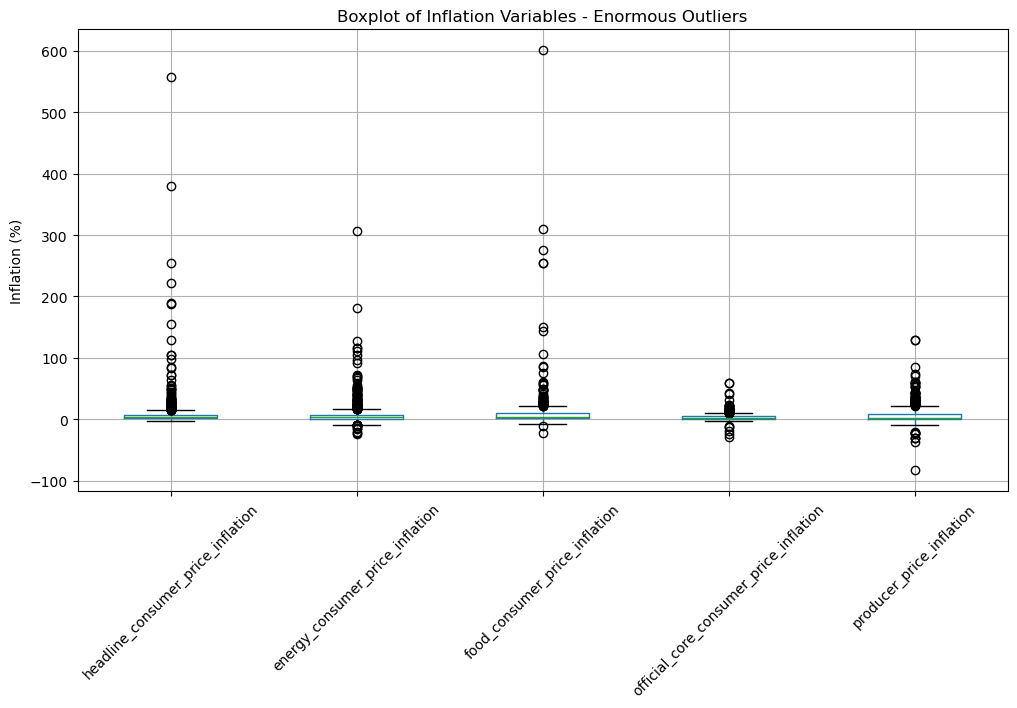

In [62]:
columns = [
    'headline_consumer_price_inflation', 
    'energy_consumer_price_inflation', 
    'food_consumer_price_inflation', 
    'official_core_consumer_price_inflation',
    'producer_price_inflation'
]

plt.figure(figsize=(12, 6))
whii_data[columns].boxplot()
plt.title('Boxplot of Inflation Variables - Enormous Outliers')
plt.ylabel('Inflation (%)')
plt.xticks(rotation=45)
plt.show()

The boxplot diagram looks pretty bad because there are extremely huge outliers which is a signal for enormous inflation especially in food and headline consuming.

To make the diagram look better I use a log scale diagram which compresses large values while preserving relative differences. It is useful when data has extreme outliers.

<Figure size 1200x600 with 0 Axes>

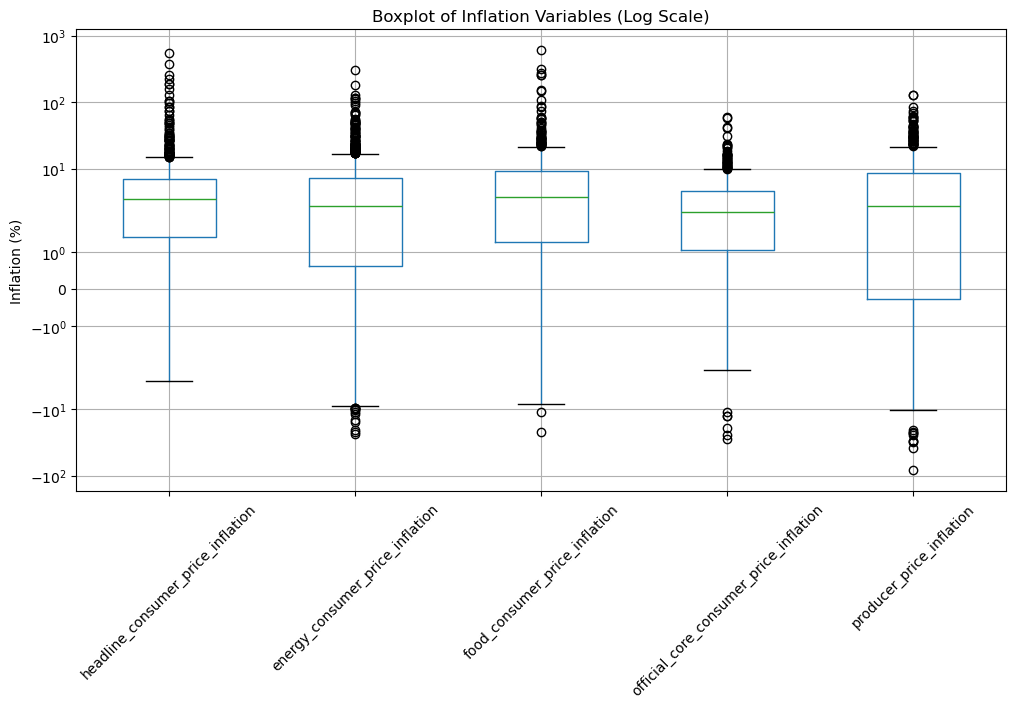

In [58]:
plt.figure(figsize=(12, 6))
whii_data[columns].boxplot()
plt.yscale('symlog')  # symmetric log scale handles negative and positive
plt.title('Boxplot of Inflation Variables (Log Scale)')
plt.ylabel('Inflation (%)')
plt.xticks(rotation=45)
plt.show()

Outliers representing by the black transparent dots are extremely huge. This leads me to the conclusion that there were some moments in the years from 2015 to 2023 when inflation hits the skies.
Now it is good to inspect these years and the countries which had the biggest inflation.